In [1]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [2]:
import cmocean
model2glodap_names = {'cfc12':'cfc12','cfc11':'cfc11','sf6':'sf6','thetao':'theta','so':'salinity'}
variable_kwargs = {
    'cfc12':{'conversion':1e12/1035,'cmap':'Greens','units':'pmol kg-1'}, #originally mol/m^3
    'cfc11':{'conversion':1e12/1035,'cmap':'PuRd','units':'pmol kg-1'},
    'sf6':{'conversion':1e12/1035 * 1e3,'cmap':'Blues','units':'fmol kg-1'},
    'theta':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'degK','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'thetao':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'salinity':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu','bins':np.arange(32,37,0.05),'anombins':np.arange(-1,1.02,0.02)}
}


In [6]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bottom_tracers_yearly.zarr"
ds = xr.open_mfdataset(ds_path)
ds = ds.sel(year = slice(None, 2099))
ds = ds.where(ds.depth < -2500)
ds["sf6"] = 1 * ds["sf6"] * variable_kwargs["sf6"]["conversion"]
ds["cfc11"] = 1 * ds["cfc11"] * variable_kwargs["cfc11"]["conversion"]
ds["cfc12"] = 1 * ds["cfc12"] * variable_kwargs["cfc12"]["conversion"]

ds["sf6"].attrs["units"] = "fmol kg-1"
ds["cfc11"].attrs["units"] = "pmol kg-1"
ds["cfc12"].attrs["units"] = "pmol kg-1"

In [7]:
def when_arrived(ds_var, threshold = 0.01):
    cond = ds_var > threshold
    year0 = cond.idxmax("year").where(cond.any("year"))

    return year0

def make_bounds(da, step, vmin = None, vmax = None):
    if vmin is None:
        vmin = float(da.min(skipna=True))
    if vmax is None:
        vmax = float(da.max(skipna=True))
    return np.arange(np.floor(vmin/step)*step, np.ceil(vmax/step)*step + step, step)

def make_sym_bounds(da, step, vmax = None):
    if vmax is None:
        vmax = float(np.nanmax(np.abs(da.values)))
    lim = np.ceil(vmax/step)*step
    return np.arange(-lim, lim + step, step)

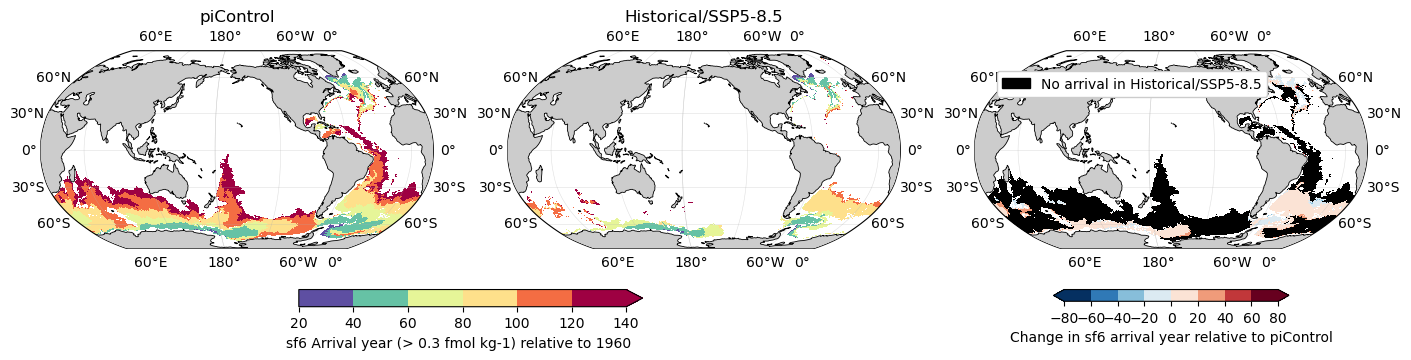

In [13]:
var = "sf6"; threshold = np.round(3 * 0.1, decimals = 2); relative_year = 1960
units = ds[var].attrs["units"]

arrival_year = when_arrived(ds[var], threshold=threshold).compute()
arrival_year = arrival_year - relative_year 

diff =  arrival_year.sel(expt="forced") - arrival_year.sel(expt="control") #if forced > control, then diff should be greater than zero
diff = diff.where(np.abs(diff) > 0)

step = 20
bounds = make_bounds(arrival_year, step)
dbounds = make_sym_bounds(diff, step, vmax = 80)

cmaps  = {"control": ("Spectral_r", bounds), "forced": ("Spectral_r", bounds), "diff": ("RdBu_r", dbounds)}
titles = {"control": "piControl",       "forced": "Historical/SSP5-8.5",       "diff": ""}
extend = {"control": "max",
          "forced": "max",
          "diff": "both",}

proj_data = ccrs.PlateCarree()
proj_map  = ccrs.Robinson(central_longitude = -160)

fields = {"control": arrival_year.sel(expt="control"),
          "forced":  arrival_year.sel(expt="forced"),
          "diff":    diff}

fig, ax = plt.subplots(1, 3, figsize=(14, 4), subplot_kw={"projection": proj_map}, constrained_layout=True)

pcs = {}
for i, key in enumerate(["control", "forced", "diff"]):
    cname, b = cmaps[key]
    cmap = plt.get_cmap(cname, len(b) - 1)
    norm = BoundaryNorm(b, ncolors=cmap.N, clip=False)

    pcs[key] = ax[i].pcolormesh(
        arrival_year["geolon"], arrival_year["geolat"], fields[key],
        transform=proj_data, cmap=cmap, norm=norm
    )
    ax[i].add_feature(cfeature.LAND, facecolor="0.8", zorder=3)
    ax[i].coastlines(linewidth=0.6, zorder=4)
    ax[i].gridlines(draw_labels=True, linewidth=0.4, alpha=0.4)
    ax[i].set_title(titles[key])

cb0 = fig.colorbar(pcs["forced"], ax=ax[:2], ticks=bounds, shrink=0.4, pad=0.06, extend = "max", orientation = "horizontal")
cb0.set_label(f"{var} Arrival year (> {threshold} {units}) relative to {relative_year}  ")

cb1 = fig.colorbar(pcs["diff"], ax=ax[2], ticks=dbounds, shrink=0.6, pad=0.06, extend = "both", orientation = "horizontal")
cb1.set_label(f"Change in {var} arrival year relative to piControl")

undetected_in_forced = (~np.isnan(arrival_year.sel(expt="control"))) * (np.isnan(arrival_year.sel(expt="forced")))
overlay = xr.where(undetected_in_forced.astype(bool), 1.0, np.nan)

unvent_color = "#000000"
unvent_cmap = ListedColormap([unvent_color])

ax[2].pcolormesh(
    overlay["geolon"], overlay["geolat"], overlay,
    transform=proj_data, cmap=unvent_cmap, shading="auto",
    zorder=6
)

leg = ax[2].legend(
    handles=[Patch(facecolor=unvent_color, edgecolor=unvent_color, label="No arrival in Historical/SSP5-8.5")],
    loc="upper center",
    bbox_to_anchor=(0.4, 0.93),
    frameon=True)
leg.get_frame().set_alpha(1.0)


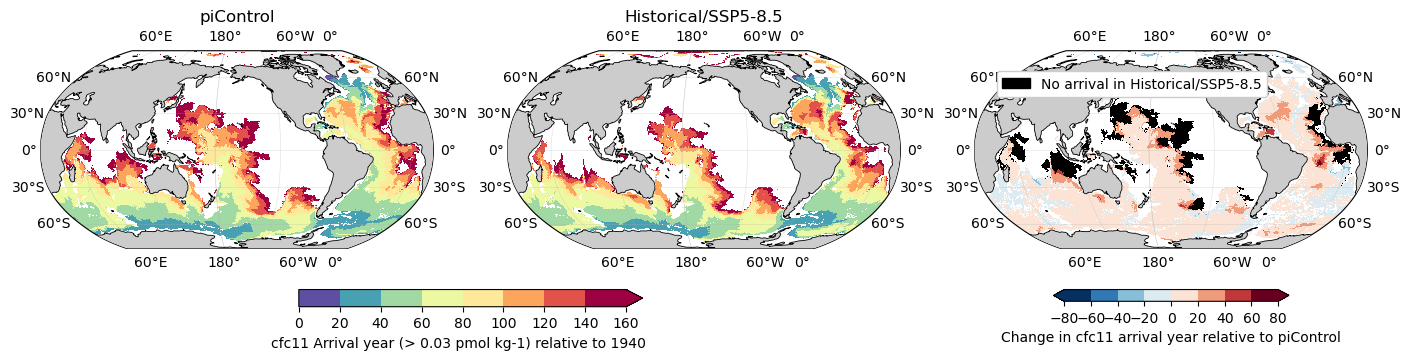

In [14]:
var = "cfc11"; threshold = np.round(3 * 0.01, decimals = 2); relative_year = 1940
units = ds[var].attrs["units"]

arrival_year = when_arrived(ds[var], threshold=threshold).compute()
arrival_year = arrival_year - relative_year 
diff =  arrival_year.sel(expt="forced") - arrival_year.sel(expt="control") #if forced > control, then diff should be greater than zero
diff = diff.where(np.abs(diff) > 0)
step = 20
bounds = make_bounds(arrival_year, step)
dbounds = make_sym_bounds(diff, step, vmax = 80)

cmaps  = {"control": ("Spectral_r", bounds), "forced": ("Spectral_r", bounds), "diff": ("RdBu_r", dbounds)}
titles = {"control": "piControl",       "forced": "Historical/SSP5-8.5",       "diff": ""}
extend = {"control": "max",
          "forced": "max",
          "diff": "both",}

proj_data = ccrs.PlateCarree()
proj_map  = ccrs.Robinson(central_longitude = -160)

fields = {"control": arrival_year.sel(expt="control"),
          "forced":  arrival_year.sel(expt="forced"),
          "diff":    diff}

fig, ax = plt.subplots(1, 3, figsize=(14, 4), subplot_kw={"projection": proj_map}, constrained_layout=True)

pcs = {}
for i, key in enumerate(["control", "forced", "diff"]):
    cname, b = cmaps[key]
    cmap = plt.get_cmap(cname, len(b) - 1)
    norm = BoundaryNorm(b, ncolors=cmap.N, clip=False)

    pcs[key] = ax[i].pcolormesh(
        arrival_year["geolon"], arrival_year["geolat"], fields[key],
        transform=proj_data, cmap=cmap, norm=norm
    )
    ax[i].add_feature(cfeature.LAND, facecolor="0.8", zorder=3)
    ax[i].coastlines(linewidth=0.6, zorder=4)
    ax[i].gridlines(draw_labels=True, linewidth=0.4, alpha=0.4)
    ax[i].set_title(titles[key])

cb0 = fig.colorbar(pcs["forced"], ax=ax[:2], ticks=bounds, shrink=0.4, pad=0.06, extend = "max", orientation = "horizontal")
cb0.set_label(f"{var} Arrival year (> {threshold} {units}) relative to {relative_year}  ")

cb1 = fig.colorbar(pcs["diff"], ax=ax[2], ticks=dbounds, shrink=0.6, pad=0.06, extend = "both", orientation = "horizontal")
cb1.set_label(f"Change in {var} arrival year relative to piControl")

undetected_in_forced = (~np.isnan(arrival_year.sel(expt="control"))) * (np.isnan(arrival_year.sel(expt="forced")))
overlay = xr.where(undetected_in_forced.astype(bool), 1.0, np.nan)

unvent_color = "#000000"
unvent_cmap = ListedColormap([unvent_color])
ax[2].pcolormesh(
    overlay["geolon"], overlay["geolat"], overlay,
    transform=proj_data, cmap=unvent_cmap, shading="auto",
    zorder=6
)

leg = ax[2].legend(
    handles=[Patch(facecolor=unvent_color, edgecolor=unvent_color, label="No arrival in Historical/SSP5-8.5")],
    loc="upper center",
    bbox_to_anchor=(0.4, 0.93),
    frameon=True,
)
leg.get_frame().set_alpha(1.0)
